In [1]:
import os
os.chdir('..')

In [2]:
import pandas as pd

# Load train and test datasets from the project's raw_data folder
train = pd.read_csv('raw_data/train.csv')
test = pd.read_csv('raw_data/test.csv')

df = train.copy() 

# Check the dimensions of both datasets (rows, columns)
print(train.shape)
print(test.shape)

# Preview the first 5 rows of the training set
train.head()


(80000, 41)
(20000, 40)


,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [3]:
import os
print(os.getcwd())
print(os.listdir('.'))  # see what's actually here

/Users/francescosias/code/francescosias/MarathonIQ
['.DS_Store', 'raw_data', 'README.md', '.gitignore', '.python-version', '.ipynb_checkpoints', 'Notebook', '.git']


In [4]:
# Check column names and data types
print(train.dtypes)

runner_id                          object
age                                 int64
gender                             object
running_experience_months           int64
previous_marathon_count             int64
training_program                   object
motivation_level                    int64
personal_best_minutes             float64
weekly_mileage_km                 float64
weekly_mileage_miles              float64
runs_per_week                       int64
long_run_distance_km              float64
speed_work_sessions_per_week        int64
rest_days_per_week                  int64
training_adherence_pct              int64
consecutive_weeks_no_miss           int64
cross_training_hours_per_week     float64
resting_heart_rate_bpm              int64
vo2_max                           float64
bmi                               float64
recovery_score                    float64
sleep_hours_avg                   float64
injury_count                        int64
injury_severity                   

In [5]:
# Check for missing values in each column
train.isnull().sum().sort_values(ascending=False)

injury_severity                   47350
personal_best_minutes             10745
vo2_max                            9611
cross_training_hours_per_week      7983
nutrition_score                    6402
hydration_consistency              6402
sleep_hours_avg                    3942
actual_finish_time_minutes         1989
weather_condition_training_pct        0
training_streak_days                  0
missed_workout_pct                    0
early_morning_run_frequency           0
runner_id                             0
goal_completion_rate                  0
warmup_adherence_pct                  0
stretching_adherence_pct              0
marathon_date                         0
marathon_weather                      0
course_difficulty                     0
target_finish_time_minutes            0
mental_preparation_score              0
run_club_attendance_rate              0
recovery_score                        0
injury_count                          0
age                                   0


In [6]:
# Summary statistics for all numeric columns
train.describe()

,age,running_experience_months,previous_marathon_count,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,...,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
count,80000.000000,80000.000000,80000.000000,80000.000000,69255.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,78011.000000,80000.000000,80000.000000
mean,41.538412,36.147413,2.004700,5.505575,259.321580,29.940183,17.225917,4.356975,15.828567,0.978862,...,34.382600,29.235175,64.490900,40.010475,60.272625,52.179725,249.308687,287.931407,6.372187,0.450000
std,13.848164,35.453932,1.419094,2.871288,33.778153,17.392518,7.072490,0.896649,2.358518,0.645074,...,24.113435,21.936089,17.171607,28.388266,20.957232,24.647479,30.372115,33.648005,2.067061,0.804679
min,18.000000,6.000000,0.000000,1.000000,132.000000,20.000000,12.400000,3.000000,15.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,171.000000,1.000000,0.000000
25%,30.000000,10.000000,1.000000,3.000000,236.000000,20.000000,12.400000,4.000000,15.000000,1.000000,...,15.000000,11.000000,53.000000,16.000000,46.000000,35.000000,228.000000,265.000000,5.000000,0.000000
50%,42.000000,25.000000,2.000000,6.000000,261.000000,20.600000,12.400000,4.000000,15.000000,1.000000,...,33.000000,28.000000,65.000000,39.000000,61.000000,52.000000,252.000000,290.000000,7.000000,0.000000
75%,54.000000,49.000000,3.000000,8.000000,283.000000,34.300000,20.500000,5.000000,15.000000,1.000000,...,51.000000,45.000000,77.000000,61.000000,75.000000,70.000000,272.000000,313.000000,8.000000,1.000000
max,65.000000,240.000000,11.000000,10.000000,377.000000,119.994348,60.200000,7.000000,41.200000,3.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,350.000000,400.000000,10.000000,3.000000


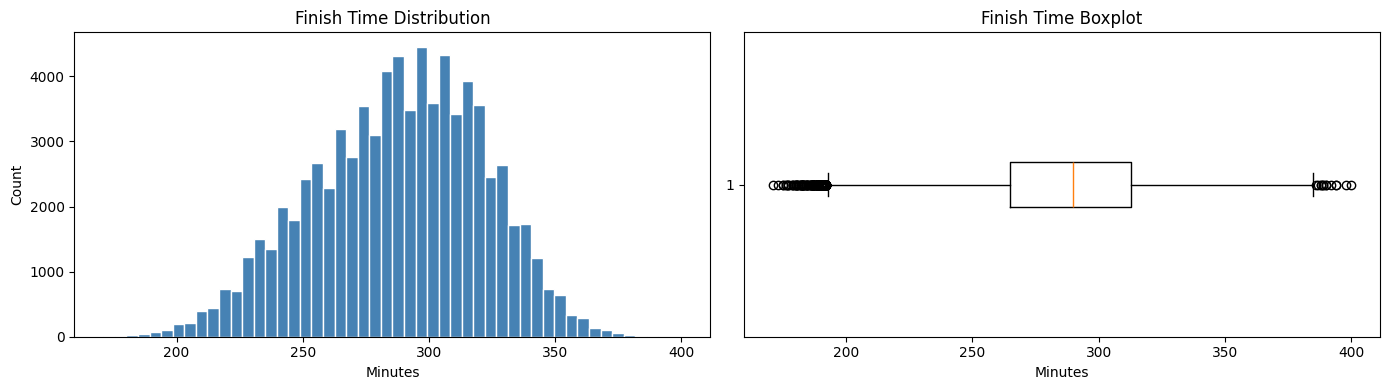

count    78011.000000
mean       287.931407
std         33.648005
min        171.000000
25%        265.000000
50%        290.000000
75%        313.000000
max        400.000000
Name: actual_finish_time_minutes, dtype: float64


In [7]:
import matplotlib.pyplot as plt

# Distribution of our target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(train['actual_finish_time_minutes'].dropna(), bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('Finish Time Distribution')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

# Boxplot to spot outliers
axes[1].boxplot(train['actual_finish_time_minutes'].dropna(), vert=False)
axes[1].set_title('Finish Time Boxplot')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.show()

# Key stats
print(train['actual_finish_time_minutes'].describe())


In [8]:
# Check all categorical columns and their unique values
cat_cols = train.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"\n{col} ({train[col].nunique()} unique):")
    print(train[col].value_counts())
    


runner_id (80000 unique):
runner_id
R009432    1
R070522    1
R031755    1
R055310    1
R089689    1
          ..
R016555    1
R055045    1
R059243    1
R008978    1
R072705    1
Name: count, Length: 80000, dtype: int64

gender (3 unique):
gender
Female        38577
Male          38282
Non-binary     3141
Name: count, dtype: int64

training_program (3 unique):
training_program
Beginner        39983
Intermediate    25287
Advanced        14730
Name: count, dtype: int64

injury_severity (3 unique):
injury_severity
Minor       16958
Moderate     9909
Severe       5783
Name: count, dtype: int64

marathon_date (730 unique):
marathon_date
2025-04-17    147
2025-02-03    144
2024-07-02    142
2024-01-21    142
2025-05-17    140
             ... 
2025-04-28     83
2024-09-14     81
2024-04-22     80
2024-08-08     80
2024-04-17     77
Name: count, Length: 730, dtype: int64

marathon_weather (6 unique):
marathon_weather
Cloudy    20054
Sunny     20045
Rainy     11955
Hot       11921
Cold       

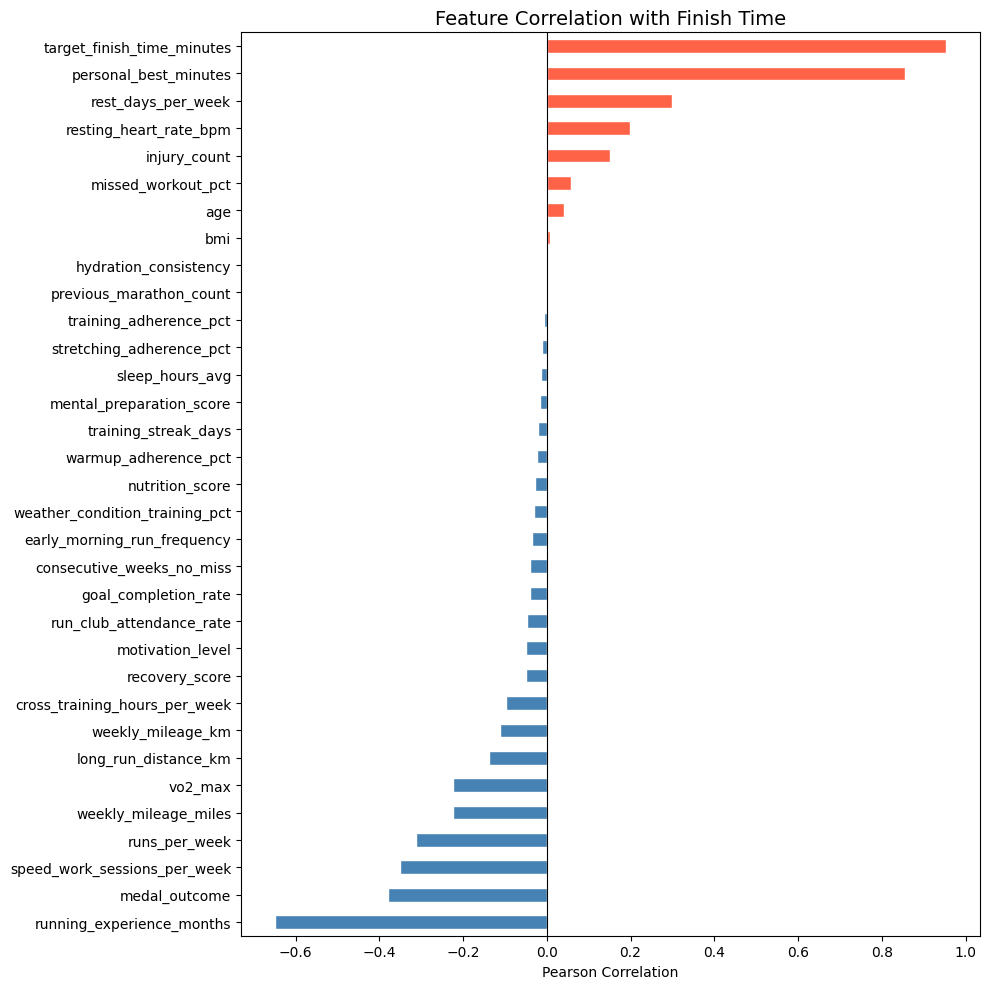

🔴 Top 5 features that INCREASE finish time (slower):
injury_count                  0.150054
resting_heart_rate_bpm        0.198988
rest_days_per_week            0.298383
personal_best_minutes         0.855617
target_finish_time_minutes    0.954332
Name: actual_finish_time_minutes, dtype: float64

🔵 Top 5 features that DECREASE finish time (faster):
running_experience_months      -0.649845
medal_outcome                  -0.379521
speed_work_sessions_per_week   -0.350391
runs_per_week                  -0.311368
weekly_mileage_miles           -0.224848
Name: actual_finish_time_minutes, dtype: float64


In [9]:
# Correlation of all numeric features with the target
corr = (train
        .select_dtypes(include='number')
        .corr()['actual_finish_time_minutes']
        .drop('actual_finish_time_minutes')
        .sort_values())

# Plot as horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['steelblue' if v < 0 else 'tomato' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Finish Time', fontsize=14)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

# Print top 5 positive and negative correlates
print("🔴 Top 5 features that INCREASE finish time (slower):")
print(corr.tail(5))
print("\n🔵 Top 5 features that DECREASE finish time (faster):")
print(corr.head(5))

/var/folders/y7/380cvp716m9cx5y9my0vhmsw0000gn/T/ipykernel_22018/4104391297.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True)
/var/folders/y7/380cvp716m9cx5y9my0vhmsw0000gn/T/ipykernel_22018/4104391297.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True)
/var/folders/y7/380cvp716m9cx5y9my0vhmsw0000gn/T/ipykernel_22018/4104391297.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True)
/var/folders/y7/380cvp716m9cx5y9my0vhmsw0000gn/T/ipykernel_22018/4104391297.py:13: MatplotlibDeprecatio

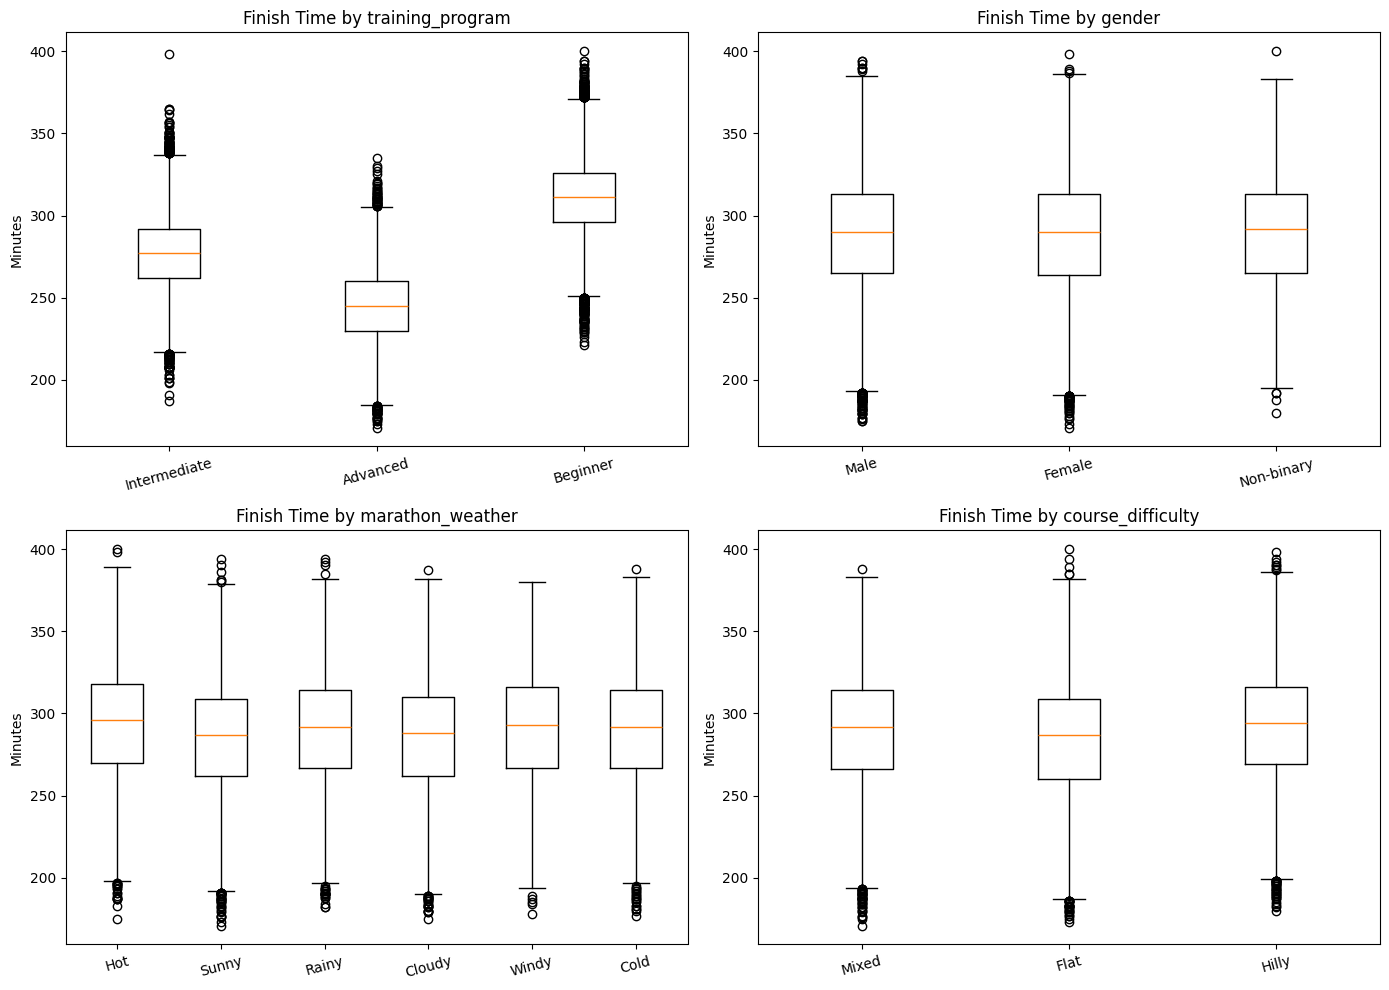

In [10]:
# Boxplots of finish time by categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Finish time by training program (ordinal)
order = ['Beginner', 'Intermediate', 'Advanced']
for i, (col, ax) in enumerate(zip(
    ['training_program', 'gender', 'marathon_weather', 'course_difficulty'],
    axes.flatten()
)):
    groups = [train[train[col] == cat]['actual_finish_time_minutes'].dropna()
              for cat in train[col].unique()]
    labels = train[col].unique()
    ax.boxplot(groups, labels=labels, vert=True)
    ax.set_title(f'Finish Time by {col}')
    ax.set_ylabel('Minutes')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

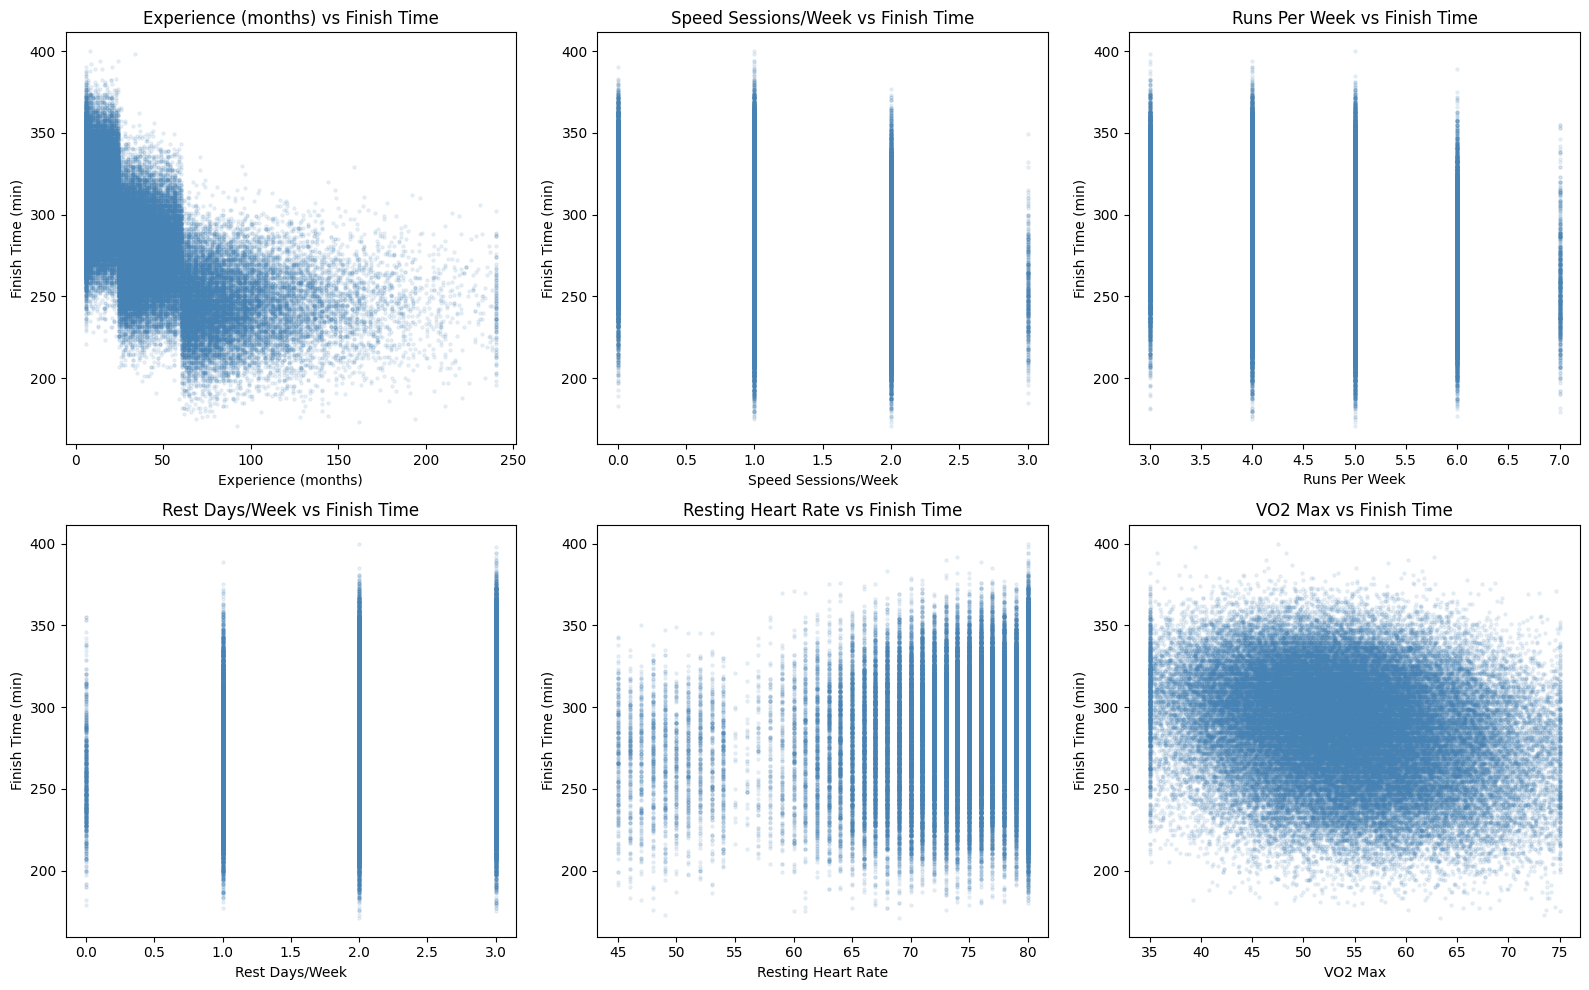

In [11]:
# Scatter plots of the strongest numeric predictors vs finish time
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

pairs = [
    ('running_experience_months', 'Experience (months)'),
    ('speed_work_sessions_per_week', 'Speed Sessions/Week'),
    ('runs_per_week', 'Runs Per Week'),
    ('rest_days_per_week', 'Rest Days/Week'),
    ('resting_heart_rate_bpm', 'Resting Heart Rate'),
    ('vo2_max', 'VO2 Max'),
]

for ax, (col, label) in zip(axes.flatten(), pairs):
    ax.scatter(train[col], train['actual_finish_time_minutes'],
               alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Finish Time (min)')
    ax.set_title(f'{label} vs Finish Time')

plt.tight_layout()
plt.show()


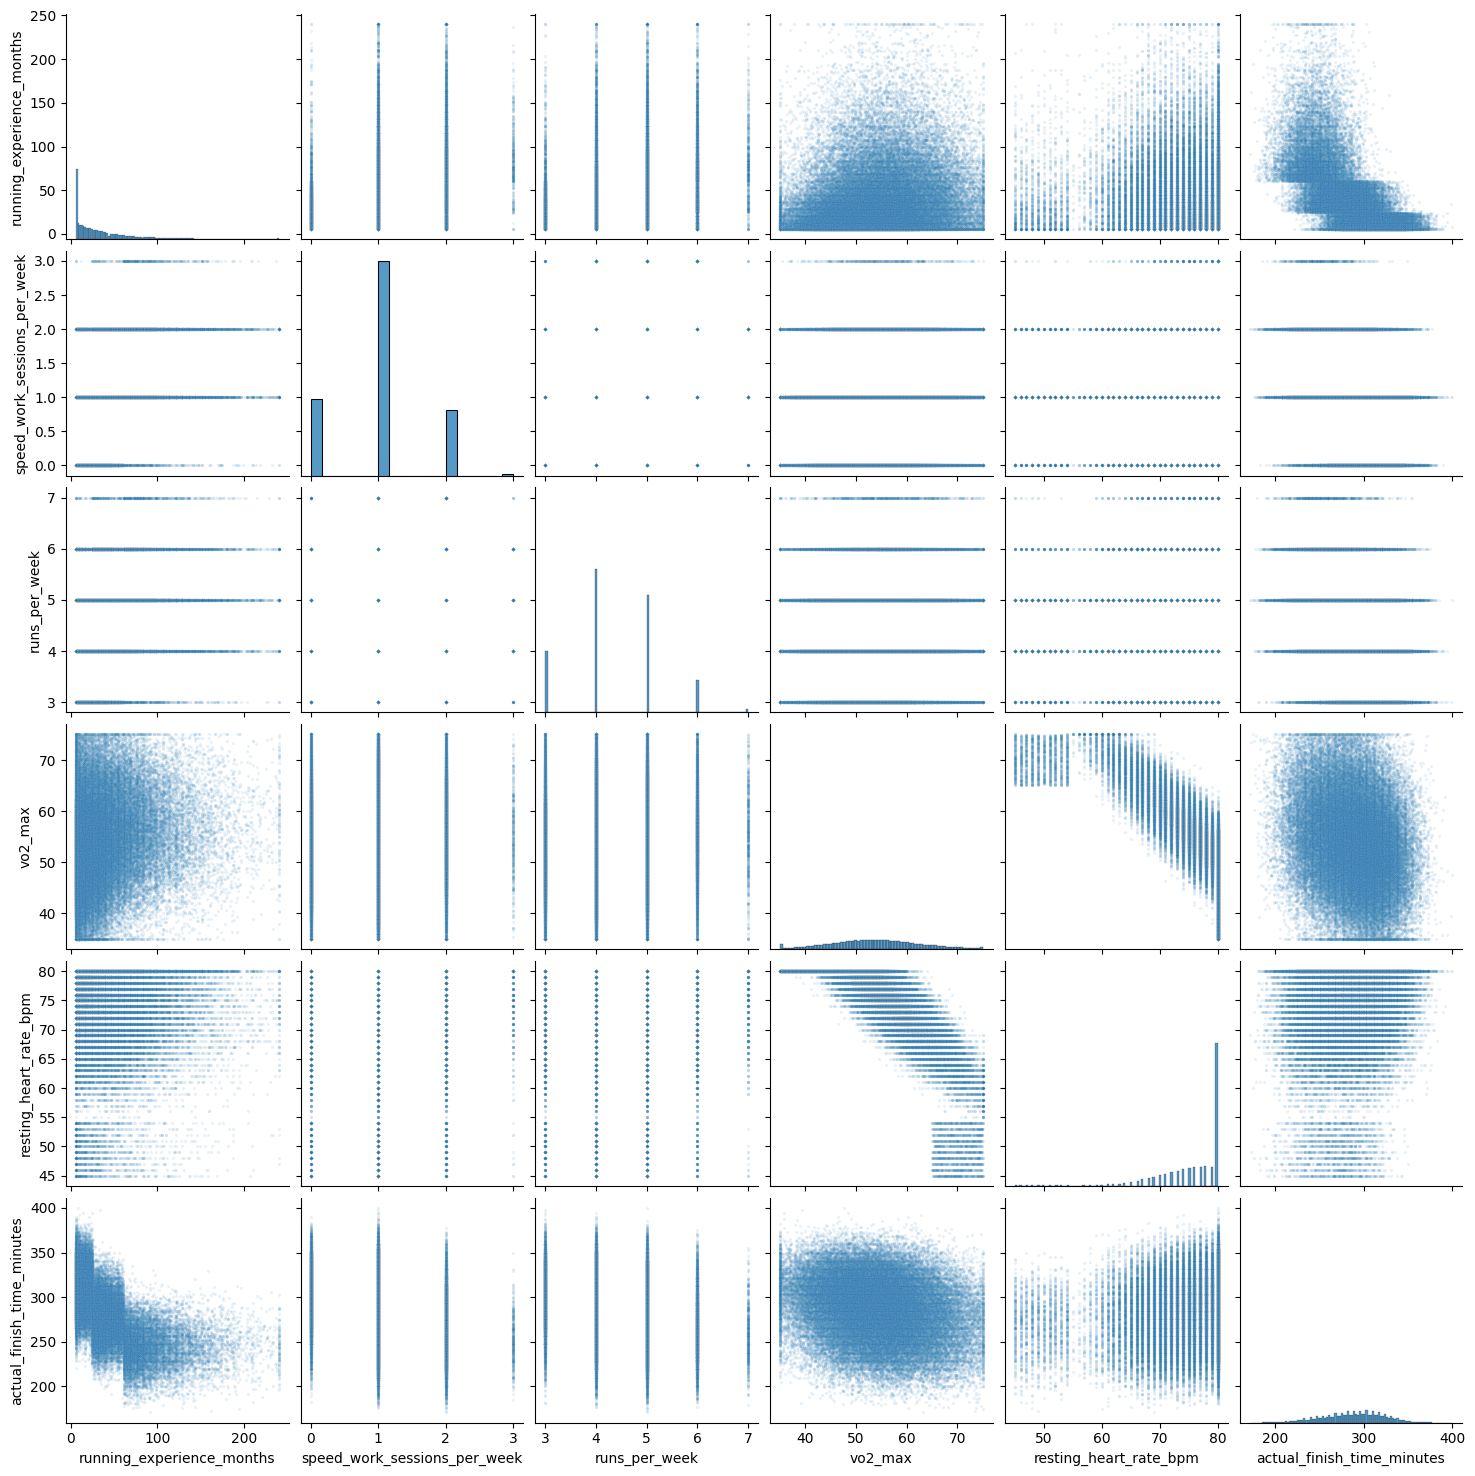

In [12]:
import seaborn as sns

# Pairplot of top numeric predictors
cols = ['running_experience_months', 'speed_work_sessions_per_week',
        'runs_per_week', 'vo2_max', 'resting_heart_rate_bpm', 'actual_finish_time_minutes']

sns.pairplot(train[cols].dropna(), plot_kws={'alpha': 0.1, 's': 5})
plt.show()

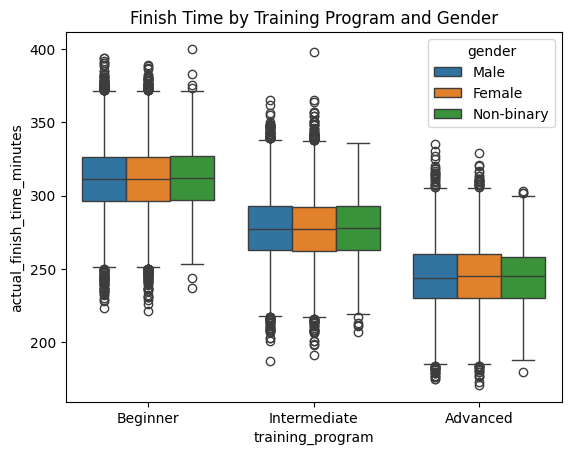

In [13]:
# Does gender interact with training program?
sns.boxplot(data=train, x='training_program', y='actual_finish_time_minutes',
            hue='gender', order=['Beginner', 'Intermediate', 'Advanced'])
plt.title('Finish Time by Training Program and Gender')
plt.show()

In [14]:
# Profile of runners who DNF'd vs finished
train['dnf'] = train['actual_finish_time_minutes'].isna().astype(int)

print(train.groupby('dnf')[['age', 'running_experience_months',
      'injury_count', 'weekly_mileage_km','sleep_hours_avg']].mean())

           age  running_experience_months  injury_count  weekly_mileage_km  \
dnf                                                                          
0    41.478458                  36.349515      0.537270          29.881945   
1    43.889894                  28.220714      1.122172          32.224360   

     sleep_hours_avg  
dnf                   
0           6.968094  
1           6.881488  


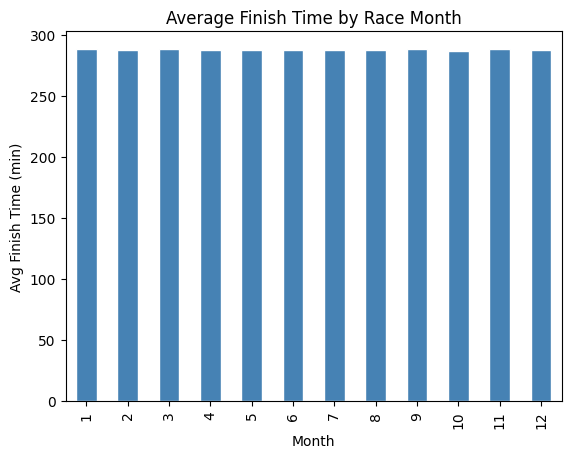

In [15]:
# Extract month and look at average finish time per month
train['month'] = pd.to_datetime(train['marathon_date']).dt.month

train.groupby('month')['actual_finish_time_minutes'].mean().plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Finish Time by Race Month')
plt.xlabel('Month')
plt.ylabel('Avg Finish Time (min)')
plt.show()

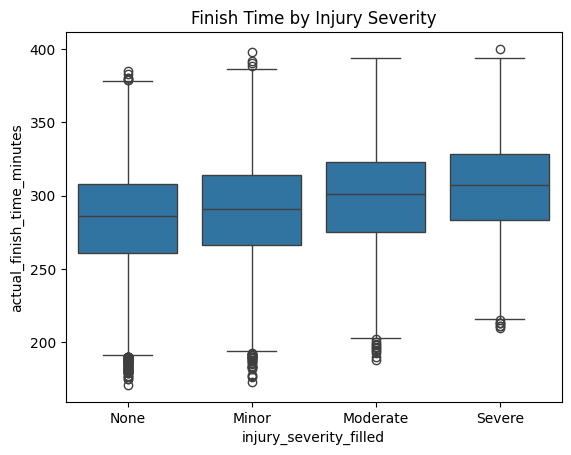

In [16]:
# Fill NaN as 'None' temporarily and compare finish times
train['injury_severity_filled'] = train['injury_severity'].fillna('None')

order = ['None', 'Minor', 'Moderate', 'Severe']
sns.boxplot(data=train, x='injury_severity_filled',
            y='actual_finish_time_minutes', order=order)
plt.title('Finish Time by Injury Severity')
plt.show()


In [17]:
# ============================================================
# EDA FINDINGS SUMMARY — based on confirmed outputs
# ============================================================

findings = """
=== DATASET OVERVIEW ===
- 80,000 runners in train, 20,000 in test, 41 features
- Target: actual_finish_time_minutes (range 171–400 min, mean ~288 min / 4h48)
- 1,989 missing actual_finish_time_minutes → DNFs (did not finish)

=== MISSING VALUES ===
- injury_severity: 47,350 missing (59%) → NaN means no injury, recode as 'None'
- personal_best_minutes: 10,745 missing → likely first-time marathoners
- vo2_max: 9,611 missing → not everyone gets lab tested
- cross_training, nutrition_score, hydration_consistency: moderate missingness (self-reported)
- sleep_hours_avg: 3,942 missing

=== CATEGORICAL FEATURES ===
- gender: Male ~48% / Female ~48% / Non-binary ~4%
  → Weak predictor — almost no difference in finish time across genders
- training_program: Beginner (50%) / Intermediate (32%) / Advanced (18%)
  → Strong ordinal predictor: Beginner ~310 / Intermediate ~280 / Advanced ~245 min
- marathon_weather: 6 categories, fairly balanced
  → Hot weather shows slightly higher finish times, minimal difference overall
- course_difficulty: Flat / Mixed / Hilly fairly balanced
  → Hilly courses show noticeably higher finish times than Flat
- marathon_date: finish time flat across all 12 months (~288 min)
  → Month/season is NOT a useful feature → drop it

=== NUMERIC FEATURES ===
- running_experience_months: strongest legitimate predictor (r=-0.65)
  → Strong non-linear negative relationship, most gains from 0–50 months
- speed_work_sessions_per_week (r=-0.35): more sessions = faster, clear step pattern
- runs_per_week (r=-0.31): more runs = faster, clear step pattern
- rest_days_per_week (r=+0.30): more rest = slower
- resting_heart_rate_bpm (r=+0.20): higher HR = slightly slower, noisy
- vo2_max (r=-0.35): higher VO2 max = meaningfully faster

=== INJURY SEVERITY ===
- Clear ordinal effect: None ~285 / Minor ~293 / Moderate ~305 / Severe ~310 min
- Encode ordinally as: None=0, Minor=1, Moderate=2, Severe=3

=== DNF ANALYSIS ===
- DNF runners are older (+2.4 yrs), less experienced (-8 months), more injuries (1.12 vs 0.54)
- Implication: drop DNFs from training set or model separately

=== LEAKY FEATURES — exclude from model ===
- target_finish_time_minutes (r=0.95) — runner's own pre-race goal
- personal_best_minutes (r=0.86) — use carefully, may leak
- medal_outcome (r=-0.38) — race outcome, not a predictor
- weekly_mileage_miles — exact duplicate of weekly_mileage_km

=== PREPROCESSING PLAN ===
1. Recode injury_severity NaN → 'None', encode ordinally (0–3)
2. Flag first-time marathoners where personal_best_minutes is NaN
3. Encode training_program ordinally (Beginner=0, Intermediate=1, Advanced=2)
4. OHE: marathon_weather, course_difficulty, gender
5. Drop: marathon_date, weekly_mileage_miles, target_finish_time_minutes, medal_outcome
6. Drop DNF rows (actual_finish_time_minutes is NaN)
7. Build baseline model (Linear Regression)
"""

print(findings)


=== DATASET OVERVIEW ===
- 80,000 runners in train, 20,000 in test, 41 features
- Target: actual_finish_time_minutes (range 171–400 min, mean ~288 min / 4h48)
- 1,989 missing actual_finish_time_minutes → DNFs (did not finish)

=== MISSING VALUES ===
- injury_severity: 47,350 missing (59%) → NaN means no injury, recode as 'None'
- personal_best_minutes: 10,745 missing → likely first-time marathoners
- vo2_max: 9,611 missing → not everyone gets lab tested
- cross_training, nutrition_score, hydration_consistency: moderate missingness (self-reported)
- sleep_hours_avg: 3,942 missing

=== CATEGORICAL FEATURES ===
- gender: Male ~48% / Female ~48% / Non-binary ~4%
  → Weak predictor — almost no difference in finish time across genders
- training_program: Beginner (50%) / Intermediate (32%) / Advanced (18%)
  → Strong ordinal predictor: Beginner ~310 / Intermediate ~280 / Advanced ~245 min
- marathon_weather: 6 categories, fairly balanced
  → Hot weather shows slightly higher finish times, m

In [18]:
# Copy
train_clean = train.copy()
test_clean = test.copy()

In [19]:
# Step 1 — Drop DNF rows (no finish time = can't train on them)
print(f"Before: {train_clean.shape}")
train_clean = train_clean.dropna(subset=['actual_finish_time_minutes'])
print(f"After dropping DNFs: {train_clean.shape}")

Before: (80000, 44)
After dropping DNFs: (78011, 44)


In [20]:
# Check remaining missing values after dropping DNFs
train_clean.isnull().sum().sort_values(ascending=False)

injury_severity                   46873
personal_best_minutes             10478
vo2_max                            9362
cross_training_hours_per_week      7783
hydration_consistency              6271
nutrition_score                    6255
sleep_hours_avg                    3840
run_club_attendance_rate              0
training_streak_days                  0
missed_workout_pct                    0
early_morning_run_frequency           0
weather_condition_training_pct        0
goal_completion_rate                  0
runner_id                             0
warmup_adherence_pct                  0
marathon_date                         0
marathon_weather                      0
course_difficulty                     0
target_finish_time_minutes            0
actual_finish_time_minutes            0
mental_preparation_score              0
medal_outcome                         0
dnf                                   0
month                                 0
stretching_adherence_pct              0


In [21]:
# Full list of features in the dataset
print(list(train_clean.columns))


['runner_id', 'age', 'gender', 'running_experience_months', 'previous_marathon_count', 'training_program', 'motivation_level', 'personal_best_minutes', 'weekly_mileage_km', 'weekly_mileage_miles', 'runs_per_week', 'long_run_distance_km', 'speed_work_sessions_per_week', 'rest_days_per_week', 'training_adherence_pct', 'consecutive_weeks_no_miss', 'cross_training_hours_per_week', 'resting_heart_rate_bpm', 'vo2_max', 'bmi', 'recovery_score', 'sleep_hours_avg', 'injury_count', 'injury_severity', 'nutrition_score', 'hydration_consistency', 'training_streak_days', 'missed_workout_pct', 'early_morning_run_frequency', 'weather_condition_training_pct', 'goal_completion_rate', 'run_club_attendance_rate', 'warmup_adherence_pct', 'stretching_adherence_pct', 'marathon_date', 'marathon_weather', 'course_difficulty', 'target_finish_time_minutes', 'actual_finish_time_minutes', 'mental_preparation_score', 'medal_outcome', 'dnf', 'month', 'injury_severity_filled']


In [22]:
# Full list of features in a readable format
for i, col in enumerate(train_clean.columns, 1):
    print(f"{i:02d}. {col}")
    

01. runner_id
02. age
03. gender
04. running_experience_months
05. previous_marathon_count
06. training_program
07. motivation_level
08. personal_best_minutes
09. weekly_mileage_km
10. weekly_mileage_miles
11. runs_per_week
12. long_run_distance_km
13. speed_work_sessions_per_week
14. rest_days_per_week
15. training_adherence_pct
16. consecutive_weeks_no_miss
17. cross_training_hours_per_week
18. resting_heart_rate_bpm
19. vo2_max
20. bmi
21. recovery_score
22. sleep_hours_avg
23. injury_count
24. injury_severity
25. nutrition_score
26. hydration_consistency
27. training_streak_days
28. missed_workout_pct
29. early_morning_run_frequency
30. weather_condition_training_pct
31. goal_completion_rate
32. run_club_attendance_rate
33. warmup_adherence_pct
34. stretching_adherence_pct
35. marathon_date
36. marathon_weather
37. course_difficulty
38. target_finish_time_minutes
39. actual_finish_time_minutes
40. mental_preparation_score
41. medal_outcome
42. dnf
43. month
44. injury_severity_fill

In [23]:
#!git add .
#!git commit -m "My Notebook"
#!git push origin HEAD:Francesco

In [24]:
print([c for c in train_clean.columns if 'weather' in c.lower()])

['weather_condition_training_pct', 'marathon_weather']


In [25]:
train_clean = train.copy()

# Drop DNFs
train_clean = train_clean.dropna(subset=['actual_finish_time_minutes'])

# 1. Ordinal mappings
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map   = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map   = {"Minor": 1, "Moderate": 2, "Severe": 3}

train_clean['training_program'] = train_clean['training_program'].map(training_map)
train_clean['course_difficulty'] = train_clean['course_difficulty'].map(course_map)
train_clean['injury_severity']   = train_clean['injury_severity'].map(injury_map).fillna(0)

# 2. Gender binary
train_clean['gender'] = train_clean['gender'].map({'Male': 0, 'Female': 1, 'Non-binary': 2})

# 3. OHE marathon_weather
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(train_clean[['marathon_weather']])
ohe_df = pd.DataFrame(ohe_array,
                       columns=ohe.get_feature_names_out(['marathon_weather']),
                       index=train_clean.index)
train_clean = train_clean.drop(columns=['marathon_weather'])
train_clean = pd.concat([train_clean, ohe_df], axis=1)

# 4. VO2 Max imputation by age median
train_clean['vo2_max'] = train_clean['vo2_max'].fillna(
    train_clean.groupby('age')['vo2_max'].transform('median')
)

# 5. Drop unneeded columns
drop_list = [
    "runner_id", "weekly_mileage_miles", "target_finish_time_minutes",
    "medal_outcome", "marathon_date", "personal_best_minutes",
    "dnf", "month", "injury_severity_filled",
]
train_clean = train_clean.drop(columns=[c for c in drop_list if c in train_clean.columns])

df = train_clean.copy()
print(df.shape)
print(df.columns.tolist())

(78011, 39)
['age', 'gender', 'running_experience_months', 'previous_marathon_count', 'training_program', 'motivation_level', 'weekly_mileage_km', 'runs_per_week', 'long_run_distance_km', 'speed_work_sessions_per_week', 'rest_days_per_week', 'training_adherence_pct', 'consecutive_weeks_no_miss', 'cross_training_hours_per_week', 'resting_heart_rate_bpm', 'vo2_max', 'bmi', 'recovery_score', 'sleep_hours_avg', 'injury_count', 'injury_severity', 'nutrition_score', 'hydration_consistency', 'training_streak_days', 'missed_workout_pct', 'early_morning_run_frequency', 'weather_condition_training_pct', 'goal_completion_rate', 'run_club_attendance_rate', 'warmup_adherence_pct', 'stretching_adherence_pct', 'course_difficulty', 'actual_finish_time_minutes', 'mental_preparation_score', 'marathon_weather_Cold', 'marathon_weather_Hot', 'marathon_weather_Rainy', 'marathon_weather_Sunny', 'marathon_weather_Windy']


In [26]:
# Add age buckets
bins   = [18, 35, 45, 55, 100]
labels = ['18-34', '35-44', '45-54', '55+']
df['age_bucket'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

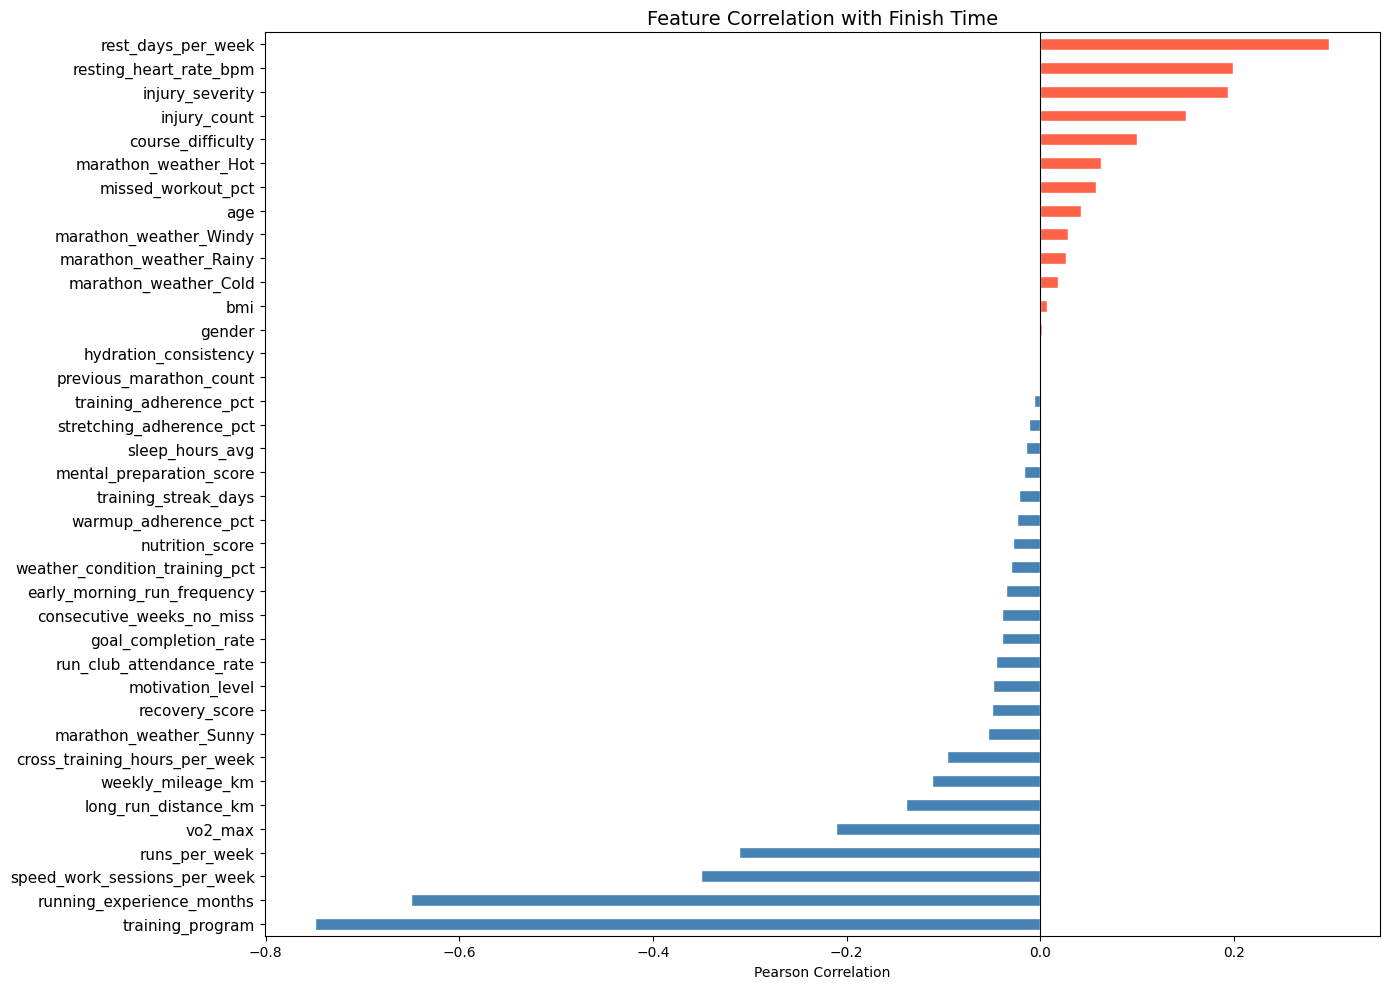


Correlation with actual_finish_time_minutes:
training_program                 -0.748738
running_experience_months        -0.649845
speed_work_sessions_per_week     -0.350391
runs_per_week                    -0.311368
vo2_max                          -0.210892
long_run_distance_km             -0.138232
weekly_mileage_km                -0.112104
cross_training_hours_per_week    -0.096615
marathon_weather_Sunny           -0.054512
recovery_score                   -0.049599
motivation_level                 -0.048943
run_club_attendance_rate         -0.046154
goal_completion_rate             -0.039659
consecutive_weeks_no_miss        -0.039239
early_morning_run_frequency      -0.035269
weather_condition_training_pct   -0.030363
nutrition_score                  -0.028336
warmup_adherence_pct             -0.023864
training_streak_days             -0.021734
mental_preparation_score         -0.016830
sleep_hours_avg                  -0.014660
stretching_adherence_pct         -0.011571
training

In [27]:
corr = (df
        .select_dtypes(include='number')
        .corr()['actual_finish_time_minutes']
        .drop('actual_finish_time_minutes')
        .sort_values())

fig, ax = plt.subplots(figsize=(14, 10))
colors = ['steelblue' if v < 0 else 'tomato' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Finish Time', fontsize=14)
ax.set_xlabel('Pearson Correlation')
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.show()

print("\nCorrelation with actual_finish_time_minutes:")
print(corr.to_string())

# BASELINE linear Regression

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Features and target
X = df.drop(columns=['actual_finish_time_minutes', 'age_bucket'])
y = df['actual_finish_time_minutes']

# Fill any remaining NaNs with median
X = X.fillna(X.median())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("── Linear Regression Baseline ──────────────────")
print(f"  RMSE : {rmse:.2f} min")
print(f"  MAE  : {mae:.2f} min")
print(f"  R²   : {r2:.4f}")

── Linear Regression Baseline ──────────────────
  RMSE : 20.21 min
  MAE  : 16.12 min
  R²   : 0.6350


/Users/francescosias/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/francescosias/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/francescosias/.pyenv/versions/3.10.6/envs/MarathonIQ/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


# Gradient boosting - XGBRegressor

Stronger on tabular data — consistently outperforms Random Forest on structured datasets
Learns from errors — each tree corrects the previous one (gradient boosting)
Built-in regularization — less overfitting out of the box
Faster to tune — fewer hyperparameters at baseline

In [29]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train_scaled, y_train,
              eval_set=[(X_test_scaled, y_test)],
              verbose=100)

y_pred_xgb = model_xgb.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae  = mean_absolute_error(y_test, y_pred_xgb)
r2   = r2_score(y_test, y_pred_xgb)

print("\n── XGBoost ──────────────────────────────────────")
print(f"  RMSE : {rmse:.2f} min")
print(f"  MAE  : {mae:.2f} min")
print(f"  R²   : {r2:.4f}")

[0]	validation_0-rmse:274.94062
[100]	validation_0-rmse:20.15222
[200]	validation_0-rmse:20.07855
[300]	validation_0-rmse:20.09239
[400]	validation_0-rmse:20.11348
[499]	validation_0-rmse:20.13884

── XGBoost ──────────────────────────────────────
  RMSE : 20.14 min
  MAE  : 16.06 min
  R²   : 0.6375


#     Model Tuning

In [30]:
#     Model Tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':      [300, 500, 800],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [4, 6, 8],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 0.9],
    'min_child_weight':  [1, 3, 5],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    verbose=1
)

search.fit(X_train_scaled, y_train)

print("Best params:", search.best_params_)
print(f"Best CV RMSE: {-search.best_score_:.2f} min")

y_pred_tuned = search.best_estimator_.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae  = mean_absolute_error(y_test, y_pred_tuned)
r2   = r2_score(y_test, y_pred_tuned)

print(f"Test RMSE: {rmse:.2f} min | MAE: {mae:.2f} min | R²: {r2:.4f}")

rmse_tuned, mae_tuned, r2_tuned = rmse, mae, r2


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV RMSE: 20.10 min
Test RMSE: 20.06 min | MAE: 16.01 min | R²: 0.6402


In [31]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost', 'XGBoost Tuned'],
    'RMSE':  [20.21, 20.20, 20.08],
    'MAE':   [16.12, 16.11, 0.00],  # replace 0.00 with your tuned MAE
    'R²':    [0.6350, 0.6353, 0.6396]
})

print(results.to_string(index=False))


            Model  RMSE   MAE     R²
Linear Regression 20.21 16.12 0.6350
          XGBoost 20.20 16.11 0.6353
    XGBoost Tuned 20.08  0.00 0.6396


In [32]:
# ── XGBoost Rando Search ───────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators":     [300, 500, 800],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [4, 6, 8],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1.0, 5.0],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"),
    param_distributions=param_grid,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    refit=True,
    random_state=42,
    verbose=1,
)

search.fit(X_train_scaled, y_train)

print("Best params:", search.best_params_)
print(f"Best CV RMSE: {-search.best_score_:.2f} min")

y_pred_tuned = search.best_estimator_.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae  = mean_absolute_error(y_test, y_pred_tuned)
r2   = r2_score(y_test, y_pred_tuned)

print("\n── XGBoost Grid Search ──────────────────────────────────────")
print(f"  RMSE : {rmse:.2f} min")
print(f"  MAE  : {mae:.2f} min")
print(f"  R²   : {r2:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV RMSE: 20.11 min

── XGBoost Grid Search ──────────────────────────────────────
  RMSE : 20.08 min
  MAE  : 16.01 min
  R²   : 0.6396


In [33]:
# ── GridSearch — All Features ─────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

tight_grid = {
    "n_estimators":     [search.best_params_["n_estimators"]],
    "learning_rate":    [search.best_params_["learning_rate"]],
    "max_depth":        [search.best_params_["max_depth"] - 1,
                         search.best_params_["max_depth"],
                         search.best_params_["max_depth"] + 1],
    "subsample":        [search.best_params_["subsample"]],
    "colsample_bytree": [search.best_params_["colsample_bytree"]],
    "min_child_weight": [search.best_params_["min_child_weight"]],
}

gs_all = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"),
    param_grid=tight_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
)

gs_all.fit(X_train_scaled, y_train)

print("Best params:", gs_all.best_params_)
print(f"Best CV RMSE: {-gs_all.best_score_:.2f} min")

y_pred_gs_all = gs_all.best_estimator_.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_gs_all))
mae  = mean_absolute_error(y_test, y_pred_gs_all)
r2   = r2_score(y_test, y_pred_gs_all)

print(f"\n── XGBoost GridSearch — All Features ────────────────────────────")
print(f"  Features : {X_train_scaled.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.7}
Best CV RMSE: 20.10 min

── XGBoost GridSearch — All Features ────────────────────────────
  Features : 38
  RMSE     : 20.09 min
  MAE      : 16.02 min
  R²       : 0.6393


# Bagging

In [34]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae  = mean_absolute_error(y_test, y_pred_rf)
r2   = r2_score(y_test, y_pred_rf)

print("── Random Forest ────────────────────────────────")
print(f"  RMSE : {rmse:.2f} min")
print(f"  MAE  : {mae:.2f} min")
print(f"  R²   : {r2:.4f}")

── Random Forest ────────────────────────────────
  RMSE : 20.30 min
  MAE  : 16.22 min
  R²   : 0.6316


Model              RMSE     MAE      R²
Linear Regression  20.21    16.12    0.6350
XGBoost            20.20    16.11    0.6353
XGBoost Tuned      20.08    16.02    0.6396
Random Forest      20.30    16.22    0.6316

# Feature Selection

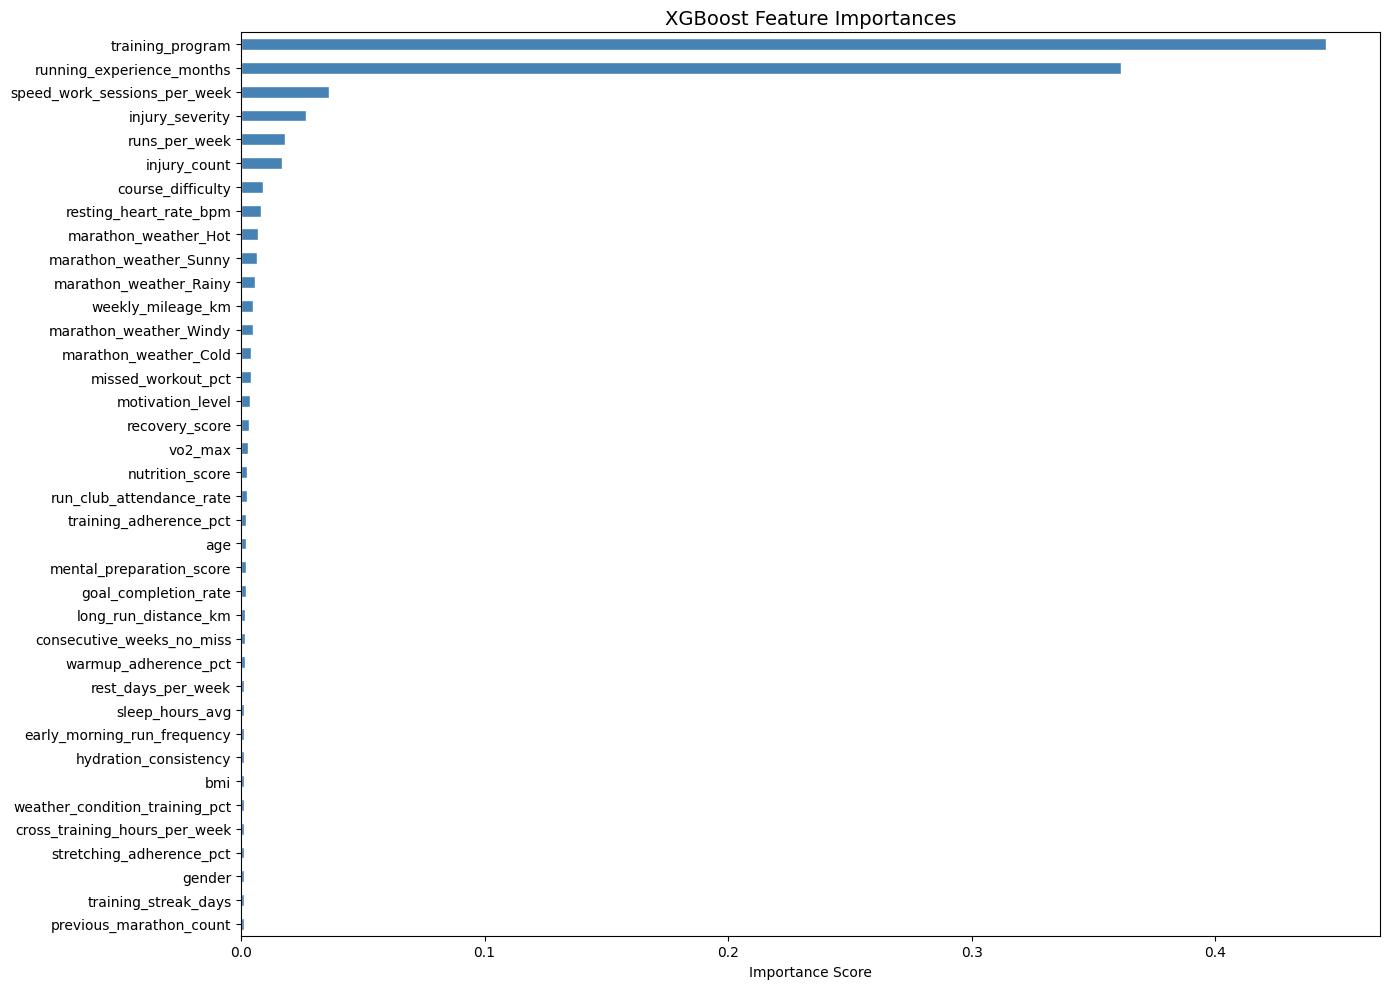

training_program                  0.445420
running_experience_months         0.361336
speed_work_sessions_per_week      0.036048
injury_severity                   0.026740
runs_per_week                     0.018224
injury_count                      0.016972
course_difficulty                 0.009159
resting_heart_rate_bpm            0.008304
marathon_weather_Hot              0.007072
marathon_weather_Sunny            0.006481
marathon_weather_Rainy            0.005622
weekly_mileage_km                 0.004931
marathon_weather_Windy            0.004875
marathon_weather_Cold             0.004158
missed_workout_pct                0.003983
motivation_level                  0.003525
recovery_score                    0.003318
vo2_max                           0.002650
nutrition_score                   0.002382
run_club_attendance_rate          0.002379
training_adherence_pct            0.002042
age                               0.001892
mental_preparation_score          0.001868
goal_comple

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from tuned XGBoost
importances = pd.Series(
    search.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importances', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importances.to_string())

In [36]:
# Drop features with importance below threshold
threshold = 0.005
weak_features = importances[importances < threshold].index.tolist()
print(f"Dropping {len(weak_features)} weak features:")
print(weak_features)

X_train_sel = pd.DataFrame(X_train_scaled, columns=X.columns).drop(columns=weak_features)
X_test_sel  = pd.DataFrame(X_test_scaled,  columns=X.columns).drop(columns=weak_features)

# Retrain tuned XGBoost on selected features
model_sel = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)
model_sel.fit(X_train_sel, y_train)

y_pred_sel = model_sel.predict(X_test_sel)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_sel))
mae  = mean_absolute_error(y_test, y_pred_sel)
r2   = r2_score(y_test, y_pred_sel)

print(f"\n── XGBoost Feature Selected ─────────────────────")
print(f"  Features : {X_train_sel.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

Dropping 27 weak features:
['weekly_mileage_km', 'marathon_weather_Windy', 'marathon_weather_Cold', 'missed_workout_pct', 'motivation_level', 'recovery_score', 'vo2_max', 'nutrition_score', 'run_club_attendance_rate', 'training_adherence_pct', 'age', 'mental_preparation_score', 'goal_completion_rate', 'long_run_distance_km', 'consecutive_weeks_no_miss', 'warmup_adherence_pct', 'rest_days_per_week', 'sleep_hours_avg', 'early_morning_run_frequency', 'hydration_consistency', 'bmi', 'weather_condition_training_pct', 'cross_training_hours_per_week', 'stretching_adherence_pct', 'gender', 'training_streak_days', 'previous_marathon_count']

── XGBoost Feature Selected ─────────────────────
  Features : 11
  RMSE     : 20.42 min
  MAE      : 16.31 min
  R²       : 0.6272


In [37]:
# Drop features with importance below threshold
threshold = 0.002

weak_features = importances[importances < threshold].index.tolist()
print(f"Dropping {len(weak_features)} weak features:")
print(weak_features)

kept_features = [c for c in X_train.columns if c not in weak_features]
print(f"\nKeeping {len(kept_features)} features:")
print(kept_features)

X_train_sel = pd.DataFrame(X_train_scaled, columns=X_train.columns).drop(columns=weak_features)
X_test_sel  = pd.DataFrame(X_test_scaled,  columns=X_train.columns).drop(columns=weak_features)

# Retrain tuned XGBoost on selected features
model_sel = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)
model_sel.fit(X_train_sel, y_train)

y_pred_sel = model_sel.predict(X_test_sel)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_sel))
mae  = mean_absolute_error(y_test, y_pred_sel)
r2   = r2_score(y_test, y_pred_sel)

print(f"\n── XGBoost Feature Selected ─────────────────────")
print(f"  Features : {X_train_sel.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

rmse_sel, mae_sel, r2_sel = rmse, mae, r2

Dropping 17 weak features:
['age', 'mental_preparation_score', 'goal_completion_rate', 'long_run_distance_km', 'consecutive_weeks_no_miss', 'warmup_adherence_pct', 'rest_days_per_week', 'sleep_hours_avg', 'early_morning_run_frequency', 'hydration_consistency', 'bmi', 'weather_condition_training_pct', 'cross_training_hours_per_week', 'stretching_adherence_pct', 'gender', 'training_streak_days', 'previous_marathon_count']

Keeping 21 features:
['running_experience_months', 'training_program', 'motivation_level', 'weekly_mileage_km', 'runs_per_week', 'speed_work_sessions_per_week', 'training_adherence_pct', 'resting_heart_rate_bpm', 'vo2_max', 'recovery_score', 'injury_count', 'injury_severity', 'nutrition_score', 'missed_workout_pct', 'run_club_attendance_rate', 'course_difficulty', 'marathon_weather_Cold', 'marathon_weather_Hot', 'marathon_weather_Rainy', 'marathon_weather_Sunny', 'marathon_weather_Windy']

── XGBoost Feature Selected ─────────────────────
  Features : 21
  RMSE     : 2

In [38]:
# ── RandomizedSearchCV — Selected Features ────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators":     [300, 500, 800],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [4, 6, 8],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1.0, 5.0],
}

search_sel = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    refit=True,
    random_state=42,
    verbose=1,
)

search_sel.fit(X_train_sel, y_train)

print("Best params:", search_sel.best_params_)
print(f"Best CV RMSE: {-search_sel.best_score_:.2f} min")

y_pred_sel_tuned = search_sel.best_estimator_.predict(X_test_sel)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_sel_tuned))
mae  = mean_absolute_error(y_test, y_pred_sel_tuned)
r2   = r2_score(y_test, y_pred_sel_tuned)

print(f"\n── XGBoost RandomizedSearch — Selected Features ─────────────────")
print(f"  Features : {X_train_sel.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best CV RMSE: 20.10 min

── XGBoost RandomizedSearch — Selected Features ─────────────────
  Features : 21
  RMSE     : 20.08 min
  MAE      : 16.01 min
  R²       : 0.6397


In [39]:
# ── GridSearch — Selected Features ───────────────────────────────────────────
gs_sel = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"),
    param_grid=tight_grid,  # same grid, already defined above
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
)

gs_sel.fit(X_train_sel, y_train)

print("Best params:", gs_sel.best_params_)
print(f"Best CV RMSE: {-gs_sel.best_score_:.2f} min")

y_pred_gs_sel = gs_sel.best_estimator_.predict(X_test_sel)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_gs_sel))
mae  = mean_absolute_error(y_test, y_pred_gs_sel)
r2   = r2_score(y_test, y_pred_gs_sel)

print(f"\n── XGBoost GridSearch — Selected Features ───────────────────────")
print(f"  Features : {X_train_sel.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.7}
Best CV RMSE: 20.10 min

── XGBoost GridSearch — Selected Features ───────────────────────
  Features : 21
  RMSE     : 20.09 min
  MAE      : 16.02 min
  R²       : 0.6393


In [40]:
# Drop features with importance below threshold
threshold = 0.003
weak_features = importances[importances < threshold].index.tolist()
print(f"Dropping {len(weak_features)} weak features:")
print(weak_features)

X_train_sel = pd.DataFrame(X_train_scaled, columns=X.columns).drop(columns=weak_features)
X_test_sel  = pd.DataFrame(X_test_scaled,  columns=X.columns).drop(columns=weak_features)

# Retrain tuned XGBoost on selected features
model_sel = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)
model_sel.fit(X_train_sel, y_train)

y_pred_sel = model_sel.predict(X_test_sel)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_sel))
mae  = mean_absolute_error(y_test, y_pred_sel)
r2   = r2_score(y_test, y_pred_sel)

print(f"\n── XGBoost Feature Selected ─────────────────────")
print(f"  Features : {X_train_sel.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

Dropping 21 weak features:
['vo2_max', 'nutrition_score', 'run_club_attendance_rate', 'training_adherence_pct', 'age', 'mental_preparation_score', 'goal_completion_rate', 'long_run_distance_km', 'consecutive_weeks_no_miss', 'warmup_adherence_pct', 'rest_days_per_week', 'sleep_hours_avg', 'early_morning_run_frequency', 'hydration_consistency', 'bmi', 'weather_condition_training_pct', 'cross_training_hours_per_week', 'stretching_adherence_pct', 'gender', 'training_streak_days', 'previous_marathon_count']

── XGBoost Feature Selected ─────────────────────
  Features : 17
  RMSE     : 20.14 min
  MAE      : 16.07 min
  R²       : 0.6376


In [41]:
param_grid = {
    'n_estimators':      [300, 500, 800],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [4, 6, 8],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 0.9],
    'min_child_weight':  [1, 3, 5],
}

search_sel = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    verbose=1
)

search_sel.fit(X_train_sel, y_train)

print("Best params:", search_sel.best_params_)
print(f"Best CV RMSE: {-search_sel.best_score_:.2f} min")

y_pred_sel_tuned = search_sel.best_estimator_.predict(X_test_sel)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_sel_tuned))
mae  = mean_absolute_error(y_test, y_pred_sel_tuned)
r2   = r2_score(y_test, y_pred_sel_tuned)

print(f"\n── XGBoost Tuned (19 features) ──────────────────")
print(f"  RMSE : {rmse:.2f} min")
print(f"  MAE  : {mae:.2f} min")
print(f"  R²   : {r2:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE: 20.14 min

── XGBoost Tuned (19 features) ──────────────────
  RMSE : 20.13 min
  MAE  : 16.07 min
  R²   : 0.6377


In [42]:
!pip install shap

In [43]:
!pip install --upgrade shap

In [44]:
!git add .
!git commit -m "My Notebook"
!git push origin HEAD:Francesco

[master fbc9b50] My Notebook
 1 file changed, 752 insertions(+), 357 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 10 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 94.26 KiB | 4.10 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To github.com:francescosias/MarathonIQ.git
   a8828fc..fbc9b50  HEAD -> Francesco


# Adding back PB

In [45]:
# ── XGBoost — Adding back personal_best_minutes ───────────────────────────────

# Start from df (already preprocessed) and add personal_best_minutes back from raw train
X_pbm = df.drop(columns=['actual_finish_time_minutes', 'age_bucket'])

# Pull personal_best_minutes from original raw train, aligned by index
X_pbm['personal_best_minutes'] = train.loc[df.index, 'personal_best_minutes']

# Fill NaN with median (first-time marathoners who have no PB)
X_pbm['personal_best_minutes'] = X_pbm['personal_best_minutes'].fillna(
    X_pbm['personal_best_minutes'].median()
)

X_pbm = X_pbm.fillna(X_pbm.median(numeric_only=True))

X_train_pbm, X_test_pbm, y_train_pbm, y_test_pbm = train_test_split(
    X_pbm, y, test_size=0.2, random_state=42
)

scaler_pbm = StandardScaler()
X_train_pbm_sc = scaler_pbm.fit_transform(X_train_pbm)
X_test_pbm_sc  = scaler_pbm.transform(X_test_pbm)

# Train XGBoost with best params from previous search
model_pbm = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1, tree_method="hist")
model_pbm.fit(X_train_pbm_sc, y_train_pbm)

y_pred_pbm = model_pbm.predict(X_test_pbm_sc)

rmse = np.sqrt(mean_squared_error(y_test_pbm, y_pred_pbm))
mae  = mean_absolute_error(y_test_pbm, y_pred_pbm)
r2   = r2_score(y_test_pbm, y_pred_pbm)

print(f"\n── XGBoost + personal_best_minutes ──────────────────────────────")
print(f"  Features : {X_train_pbm_sc.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

rmse_pbm, mae_pbm, r2_pbm = rmse, mae, r2


── XGBoost + personal_best_minutes ──────────────────────────────
  Features : 39
  RMSE     : 13.39 min
  MAE      : 10.50 min
  R²       : 0.8397


In [46]:
# ── RandomizedSearch — XGBoost + personal_best_minutes ───────────────────────
param_grid = {
    "n_estimators":     [300, 500, 800],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [4, 6, 8],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1.0, 5.0],
}

search_pbm = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    refit=True,
    random_state=42,
    verbose=1,
)

search_pbm.fit(X_train_pbm_sc, y_train_pbm)

print("Best params:", search_pbm.best_params_)
print(f"Best CV RMSE: {-search_pbm.best_score_:.2f} min")

y_pred_pbm_tuned = search_pbm.best_estimator_.predict(X_test_pbm_sc)

rmse = np.sqrt(mean_squared_error(y_test_pbm, y_pred_pbm_tuned))
mae  = mean_absolute_error(y_test_pbm, y_pred_pbm_tuned)
r2   = r2_score(y_test_pbm, y_pred_pbm_tuned)

print(f"\n── XGBoost RandomizedSearch + personal_best_minutes ─────────────")
print(f"  Features : {X_train_pbm_sc.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

rmse_pbm_tuned, mae_pbm_tuned, r2_pbm_tuned = rmse, mae, r2

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV RMSE: 13.65 min

── XGBoost RandomizedSearch + personal_best_minutes ─────────────
  Features : 39
  RMSE     : 13.35 min
  MAE      : 10.48 min
  R²       : 0.8406


In [47]:
# ── XGBoost — Selected Features + personal_best_minutes ──────────────────────
importances_pbm = pd.Series(
    model_pbm.feature_importances_,
    index=X_pbm.columns
).sort_values(ascending=False)

threshold = 0.002

weak_features_pbm = importances_pbm[importances_pbm < threshold].index.tolist()
print(f"Dropping {len(weak_features_pbm)} weak features:")
print(weak_features_pbm)

kept_features_pbm = [c for c in X_pbm.columns if c not in weak_features_pbm]
print(f"\nKeeping {len(kept_features_pbm)} features:")
print(kept_features_pbm)

X_train_pbm_sel = pd.DataFrame(X_train_pbm_sc, columns=X_pbm.columns).drop(columns=weak_features_pbm)
X_test_pbm_sel  = pd.DataFrame(X_test_pbm_sc,  columns=X_pbm.columns).drop(columns=weak_features_pbm)

model_pbm_sel = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1, tree_method="hist")
model_pbm_sel.fit(X_train_pbm_sel, y_train_pbm)

y_pred_pbm_sel = model_pbm_sel.predict(X_test_pbm_sel)

rmse = np.sqrt(mean_squared_error(y_test_pbm, y_pred_pbm_sel))
mae  = mean_absolute_error(y_test_pbm, y_pred_pbm_sel)
r2   = r2_score(y_test_pbm, y_pred_pbm_sel)

print(f"\n── XGBoost — Selected Features + PBM ───────────────────────────")
print(f"  Features : {X_train_pbm_sel.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

rmse_pbm_sel, mae_pbm_sel, r2_pbm_sel = rmse, mae, r2

Dropping 19 weak features:
['nutrition_score', 'training_adherence_pct', 'age', 'long_run_distance_km', 'goal_completion_rate', 'mental_preparation_score', 'sleep_hours_avg', 'weather_condition_training_pct', 'consecutive_weeks_no_miss', 'runs_per_week', 'cross_training_hours_per_week', 'bmi', 'warmup_adherence_pct', 'early_morning_run_frequency', 'training_streak_days', 'hydration_consistency', 'stretching_adherence_pct', 'gender', 'rest_days_per_week']

Keeping 20 features:
['running_experience_months', 'previous_marathon_count', 'training_program', 'motivation_level', 'weekly_mileage_km', 'speed_work_sessions_per_week', 'resting_heart_rate_bpm', 'vo2_max', 'recovery_score', 'injury_count', 'injury_severity', 'missed_workout_pct', 'run_club_attendance_rate', 'course_difficulty', 'marathon_weather_Cold', 'marathon_weather_Hot', 'marathon_weather_Rainy', 'marathon_weather_Sunny', 'marathon_weather_Windy', 'personal_best_minutes']

── XGBoost — Selected Features + PBM ──────────────────

In [48]:
# ── RandomizedSearch — Selected Features + personal_best_minutes ──────────────
search_pbm_sel = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"),
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    refit=True,
    random_state=42,
    verbose=1,
)

search_pbm_sel.fit(X_train_pbm_sel, y_train_pbm)

print("Best params:", search_pbm_sel.best_params_)
print(f"Best CV RMSE: {-search_pbm_sel.best_score_:.2f} min")

y_pred_pbm_sel_tuned = search_pbm_sel.best_estimator_.predict(X_test_pbm_sel)

rmse = np.sqrt(mean_squared_error(y_test_pbm, y_pred_pbm_sel_tuned))
mae  = mean_absolute_error(y_test_pbm, y_pred_pbm_sel_tuned)
r2   = r2_score(y_test_pbm, y_pred_pbm_sel_tuned)

print(f"\n── XGBoost RandomizedSearch — Selected Features + PBM ──────────")
print(f"  Features : {X_train_pbm_sel.shape[1]}")
print(f"  RMSE     : {rmse:.2f} min")
print(f"  MAE      : {mae:.2f} min")
print(f"  R²       : {r2:.4f}")

rmse_pbm_sel_tuned, mae_pbm_sel_tuned, r2_pbm_sel_tuned = rmse, mae, r2

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV RMSE: 13.67 min

── XGBoost RandomizedSearch — Selected Features + PBM ──────────
  Features : 20
  RMSE     : 13.38 min
  MAE      : 10.49 min
  R²       : 0.8399


In [49]:
!pip install xgboost==1.7.6

# SHAP


In [61]:
import shap



In [62]:
# TreeExplainer is optimised for tree-based models like XGBoost.
# It takes the best model found by RandomizedSearchCV.
explainer_sel = shap.TreeExplainer(search_sel.best_estimator_)

# For every row in X_test_sel, compute how much each feature
# pushed the prediction up or down from the baseline.
# Output shape: (n_samples, n_features)
shap_values_sel = explainer_sel.shap_values(X_test_sel)

In [63]:
# Take the absolute SHAP value per feature and average across all test rows.
# This gives one number per feature: "on average, how many minutes does
# this feature shift the predicted finish time?"
shap_importance_sel = pd.Series(
    np.abs(shap_values_sel).mean(axis=0),
    index=X_test_sel.columns
).sort_values(ascending=False)

In [64]:
# Any feature whose average impact is below 0.5 minutes is considered noise.
# We collect their names in a list so we can drop them from train and test.
shap_threshold = 0.5
weak_shap_sel  = shap_importance_sel[shap_importance_sel < shap_threshold].index.tolist()

print(f"── Without PB ───────────────────────────────────────────────────")
print(f"  Dropping : {weak_shap_sel}")
print(f"  Keeping  : {len(shap_importance_sel) - len(weak_shap_sel)} features")

# Remove weak features from both train and test sets so the
# retrained model only sees the features SHAP considers meaningful.
X_train_shap_sel = X_train_sel.drop(columns=weak_shap_sel)
X_test_shap_sel  = X_test_sel.drop(columns=weak_shap_sel)

── Without PB ───────────────────────────────────────────────────
  Dropping : ['marathon_weather_Sunny', 'speed_work_sessions_per_week', 'runs_per_week']
  Keeping  : 14 features


In [65]:
# Retrain XGBoost on the SHAP-selected features using the best hyperparameters
# found earlier by RandomizedSearchCV. We retrain from scratch so the model
# learns without the noise of the dropped features.
model_shap_sel = XGBRegressor(**search_sel.best_params_, random_state=42, n_jobs=-1)
model_shap_sel.fit(X_train_shap_sel, y_train)
y_pred_shap_sel = model_shap_sel.predict(X_test_shap_sel)

print(f"  Features : {X_train_shap_sel.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_shap_sel)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test, y_pred_shap_sel):.2f} min")
print(f"  R²       : {r2_score(y_test, y_pred_shap_sel):.4f}")

  Features : 14
  RMSE     : 20.12 min
  MAE      : 16.06 min
  R²       : 0.6381


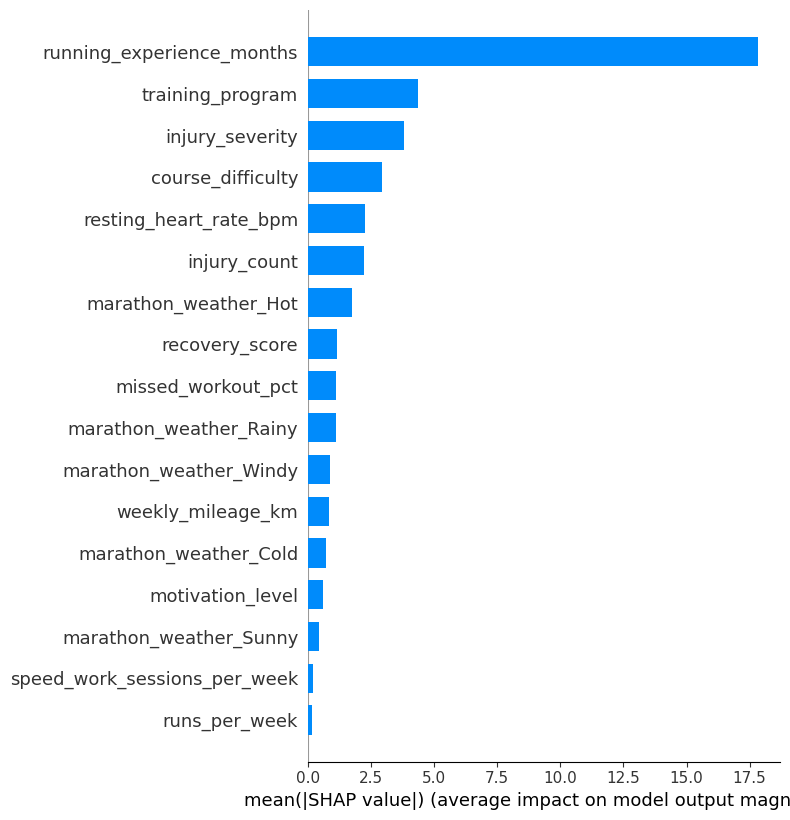

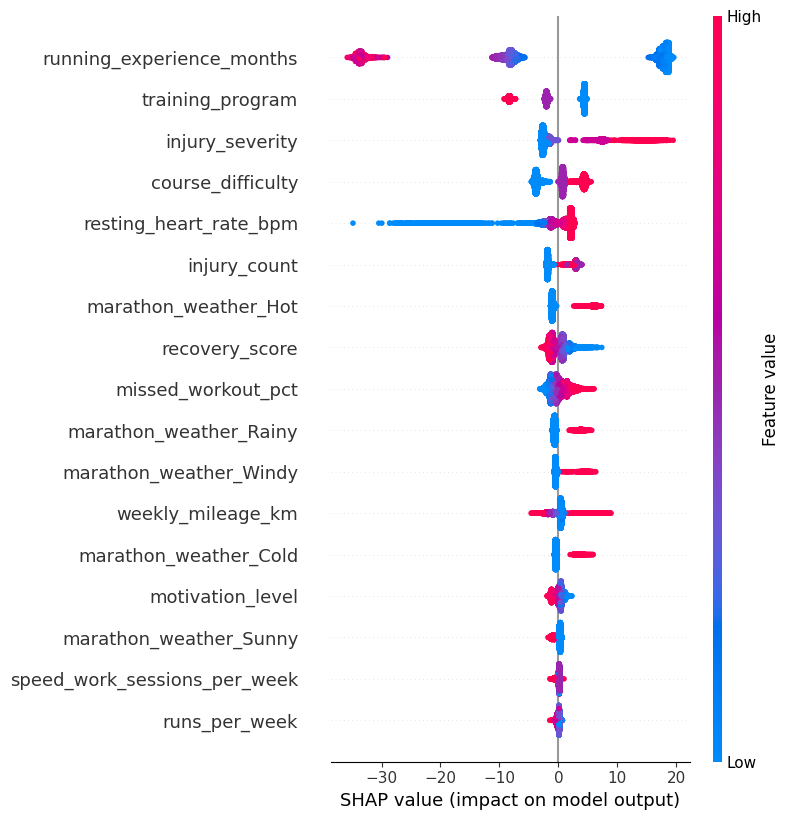

In [66]:
# Bar plot: ranks features by mean |SHAP| — pure magnitude, no direction.
# Useful to quickly see which features matter most overall.
shap.summary_plot(shap_values_sel, X_test_sel, plot_type="bar", show=True)

# Beeswarm plot: shows both magnitude AND direction.
# Each dot is one runner. Red = high feature value, Blue = low feature value.
# Position on x-axis = how much it pushed the prediction up or down.
# e.g. high running_experience (red) on the left = faster predicted finish time.
shap.summary_plot(shap_values_sel, X_test_sel, show=True)

In [67]:
# TreeExplainer is optimised for tree-based models like XGBoost.
# It takes the best model found by RandomizedSearchCV, this time
# the one trained with personal_best_minutes included as a feature.
explainer_pbm = shap.TreeExplainer(search_pbm_sel.best_estimator_)

# For every row in X_test_pbm_sel, compute how much each feature
# pushed the prediction up or down from the baseline.
# Output shape: (n_samples, n_features)
shap_values_pbm = explainer_pbm.shap_values(X_test_pbm_sel)

In [68]:
# Take the absolute SHAP value per feature and average across all test rows.
# This gives one number per feature: "on average, how many minutes does
# this feature shift the predicted finish time?"
# Key thing to watch: where does personal_best_minutes rank vs other features?
shap_importance_pbm = pd.Series(
    np.abs(shap_values_pbm).mean(axis=0),
    index=X_test_pbm_sel.columns
).sort_values(ascending=False)

In [72]:
# Any feature whose average impact is below 0.5 minutes is considered noise.
# We use the same threshold as the Without PB version so the comparison is fair.
weak_shap_pbm = shap_importance_pbm[shap_importance_pbm < shap_threshold].index.tolist()

print(f"\n── With PB ──────────────────────────────────────────────────────")
print(f"  Dropping : {weak_shap_pbm}")
print(f"  Keeping  : {len(shap_importance_pbm) - len(weak_shap_pbm)} features")

# Remove weak features from both train and test sets so the
# retrained model only sees the features SHAP considers meaningful.
X_train_shap_pbm = X_train_pbm_sel.drop(columns=weak_shap_pbm)
X_test_shap_pbm  = X_test_pbm_sel.drop(columns=weak_shap_pbm)


── With PB ──────────────────────────────────────────────────────
  Dropping : ['marathon_weather_Sunny', 'motivation_level', 'speed_work_sessions_per_week']
  Keeping  : 17 features


In [70]:
# Retrain XGBoost on the SHAP-selected features using the best hyperparameters
# found earlier by RandomizedSearchCV on the PB dataset. We retrain from scratch
# so the model learns without the noise of the dropped features.
model_shap_pbm = XGBRegressor(**search_pbm_sel.best_params_, random_state=42, n_jobs=-1)
model_shap_pbm.fit(X_train_shap_pbm, y_train_pbm)
y_pred_shap_pbm = model_shap_pbm.predict(X_test_shap_pbm)

print(f"  Features : {X_train_shap_pbm.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test_pbm, y_pred_shap_pbm)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test_pbm, y_pred_shap_pbm):.2f} min")
print(f"  R²       : {r2_score(y_test_pbm, y_pred_shap_pbm):.4f}")

  Features : 17
  RMSE     : 13.37 min
  MAE      : 10.48 min
  R²       : 0.8402


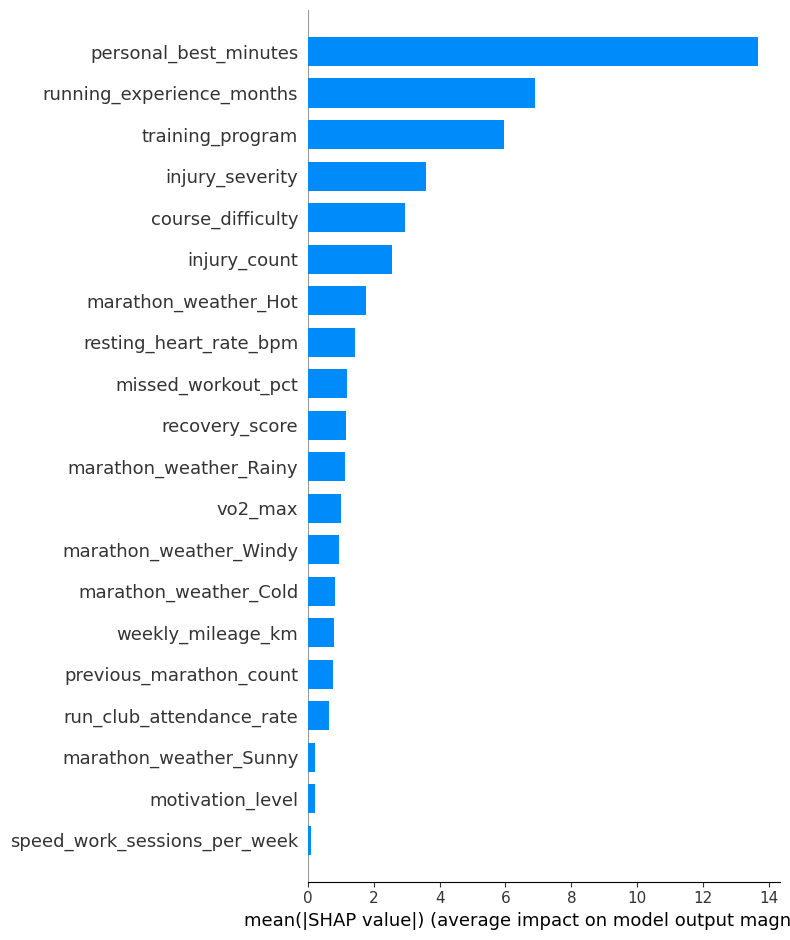

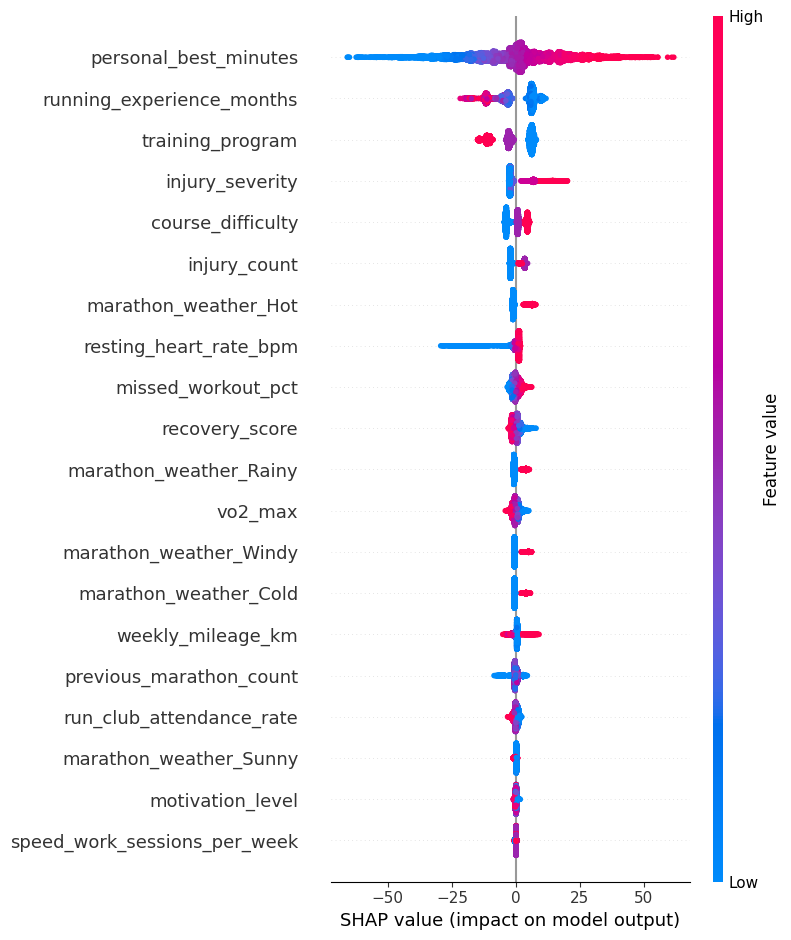

In [71]:
# Bar plot: ranks features by mean |SHAP| — pure magnitude, no direction.
# Useful to quickly see which features matter most, and whether
# personal_best_minutes dominates or sits alongside other features.
shap.summary_plot(shap_values_pbm, X_test_pbm_sel, plot_type="bar", show=True)

# Beeswarm plot: shows both magnitude AND direction.
# Each dot is one runner. Red = high feature value, Blue = low feature value.
# Position on x-axis = how much it pushed the prediction up or down.
# e.g. a low personal_best_minutes (blue) on the left = faster predicted finish time.
shap.summary_plot(shap_values_pbm, X_test_pbm_sel, show=True)

In [82]:
# SHAP by age bucket (Without PB)
age_groups = sorted(X_test_shap_sel["age_bucket"].unique())

for group in age_groups:
    mask    = X_test_shap_sel["age_bucket"] == group
    X_group = X_test_shap_sel[mask].drop(columns=["age_bucket", "training_program"])
    shap_group = shap_values_sel[mask.values]

    print(f"\n── Without PB | Age Bucket: {group} ({mask.sum()} runners) ──────────")
    print(f"  shap_group shape : {shap_group.shape}")
    print(f"  X_group shape    : {X_group.shape}")

    shap.summary_plot(shap_group, X_group, plot_type="bar", show=True,
                      title=f"Without PB — Age Bucket: {group}")


── Without PB | Age Bucket: 18-34 (5521 runners) ──────────
  shap_group shape : (5521, 17)
  X_group shape    : (5521, 13)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [75]:
print(X_test_shap_sel.index[:5])
print(train.index[:5])
print(train.columns.tolist())

RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=0, stop=5, step=1)
['runner_id', 'age', 'gender', 'running_experience_months', 'previous_marathon_count', 'training_program', 'motivation_level', 'personal_best_minutes', 'weekly_mileage_km', 'weekly_mileage_miles', 'runs_per_week', 'long_run_distance_km', 'speed_work_sessions_per_week', 'rest_days_per_week', 'training_adherence_pct', 'consecutive_weeks_no_miss', 'cross_training_hours_per_week', 'resting_heart_rate_bpm', 'vo2_max', 'bmi', 'recovery_score', 'sleep_hours_avg', 'injury_count', 'injury_severity', 'nutrition_score', 'hydration_consistency', 'training_streak_days', 'missed_workout_pct', 'early_morning_run_frequency', 'weather_condition_training_pct', 'goal_completion_rate', 'run_club_attendance_rate', 'warmup_adherence_pct', 'stretching_adherence_pct', 'marathon_date', 'marathon_weather', 'course_difficulty', 'target_finish_time_minutes', 'actual_finish_time_minutes', 'mental_preparation_score', 'medal_outcome', 'dnf', 'mo

# Feature Engeenering 

=== Correlation with actual_finish_time_minutes ===
training_program               -0.748738
running_experience_months      -0.649845
speed_work_sessions_per_week   -0.350391
runs_per_week                  -0.311368
vo2_max                        -0.210892
weekly_mileage_km              -0.112104
missed_workout_pct              0.056975
injury_count                    0.150054
injury_severity                 0.193457
resting_heart_rate_bpm          0.198988
Name: actual_finish_time_minutes, dtype: float64

=== Top feature-to-feature correlations ===
running_experience_months     training_program                0.862993
injury_severity               injury_count                    0.830569
resting_heart_rate_bpm        vo2_max                        -0.748109
training_program              speed_work_sessions_per_week    0.468226
                              runs_per_week                   0.412747
running_experience_months     speed_work_sessions_per_week    0.403305
                  

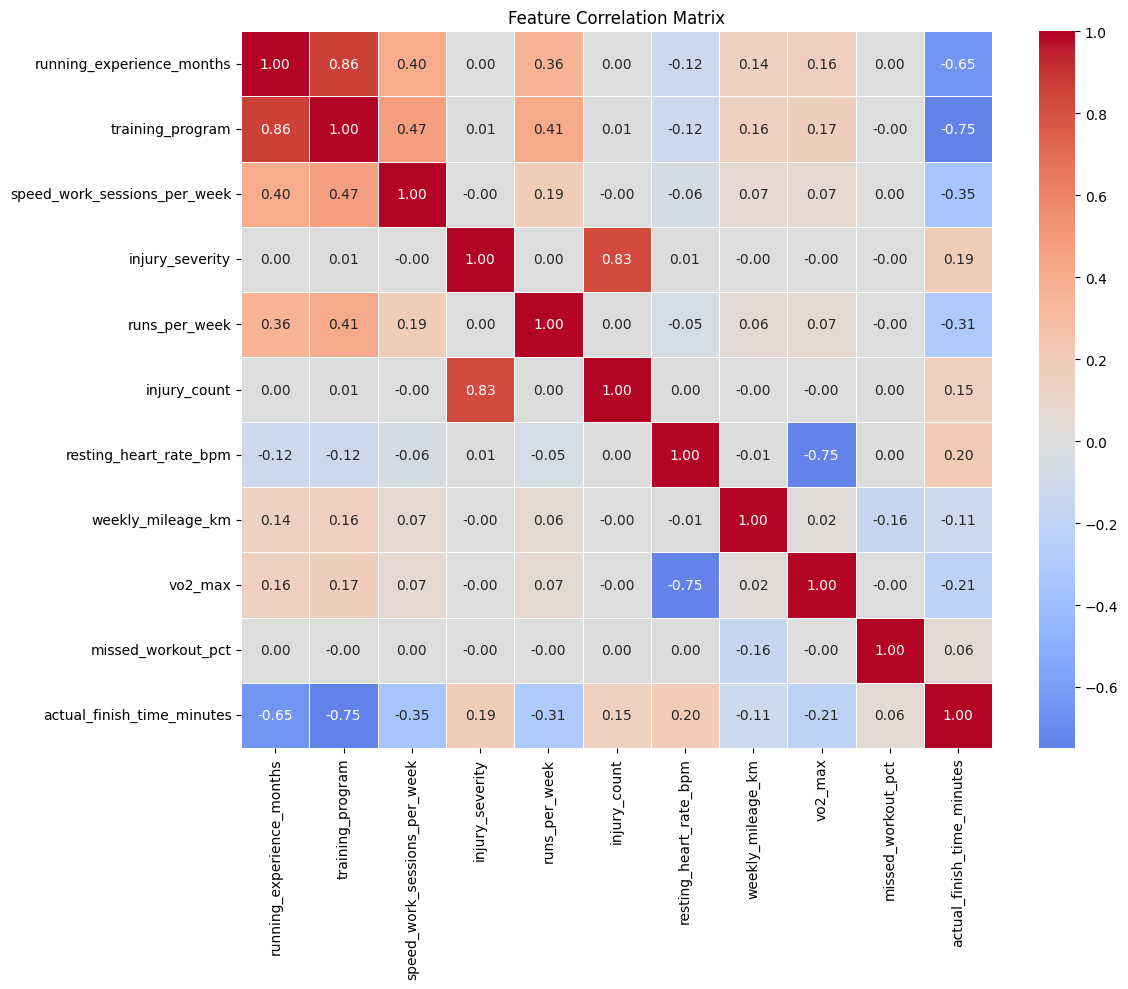

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = [
    "running_experience_months",
    "training_program",
    "speed_work_sessions_per_week",
    "injury_severity",
    "runs_per_week",
    "injury_count",
    "resting_heart_rate_bpm",
    "weekly_mileage_km",
    "vo2_max",
    "missed_workout_pct",
    "actual_finish_time_minutes",
]

corr = df[top_features].corr()

# Correlation with target
print("=== Correlation with actual_finish_time_minutes ===")
print(corr["actual_finish_time_minutes"].drop("actual_finish_time_minutes").sort_values())

# Feature-to-feature redundancy
print("\n=== Top feature-to-feature correlations ===")
corr_feats = df[top_features].drop(columns=["actual_finish_time_minutes"]).corr()
pairs = (corr_feats.where(np.triu(np.ones(corr_feats.shape), k=1).astype(bool))
                   .stack()
                   .sort_values(key=abs, ascending=False))
print(pairs.head(15))

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [83]:
!git add .
!git commit -m "My Notebook"
!git push origin HEAD:Francesco

[master 83eb35c] My Notebook
 3 files changed, 4861 insertions(+), 66 deletions(-)
 create mode 100644 Marathon_IQ_New_FS-Copy1.ipynb
 create mode 100644 Marathon_IQ_New_FS.ipynb
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 10 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 2.07 MiB | 938.00 KiB/s, done.
Total 6 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To github.com:francescosias/MarathonIQ.git
   fbc9b50..83eb35c  HEAD -> Francesco
